Epoch [1/10] 平均 Loss: 0.826134
Epoch [2/10] 平均 Loss: 0.038755
Epoch [3/10] 平均 Loss: 0.013336
Epoch [4/10] 平均 Loss: 0.010275
Epoch [5/10] 平均 Loss: 0.009470
Epoch [6/10] 平均 Loss: 0.009044
Epoch [7/10] 平均 Loss: 0.008650
Epoch [8/10] 平均 Loss: 0.007952
Epoch [9/10] 平均 Loss: 0.007537
Epoch [10/10] 平均 Loss: 0.007058


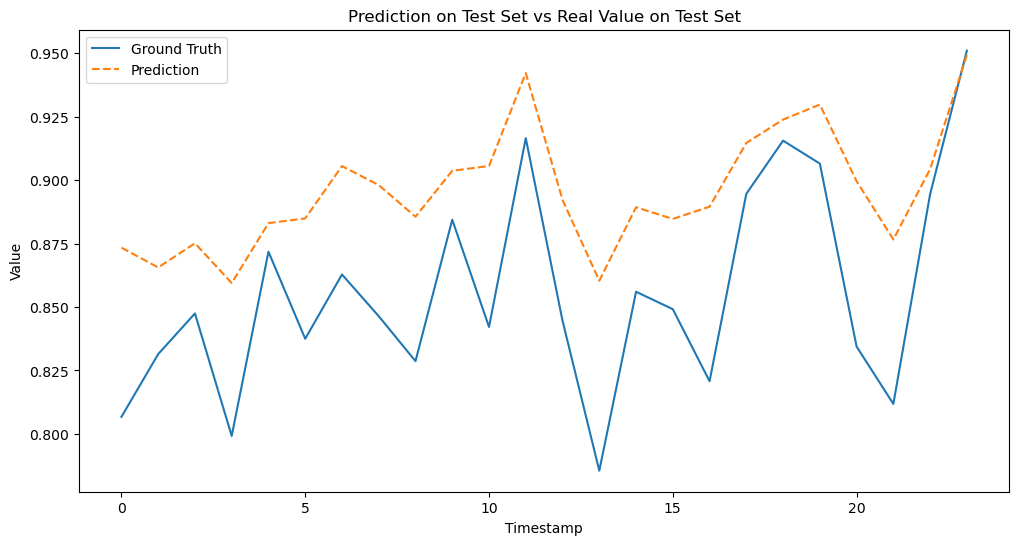

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# =============================================================================
# 1. ProbSparse Attention 實作（包含選取 Top-u 查詢策略，簡化版）
# =============================================================================
class ProbSparseAttention(nn.Module):
    def __init__(self, mask_flag=True, factor=5, scale=None, attention_dropout=0.1):
        """
        mask_flag: 是否使用 mask (對 Decoder 自注意力非常重要)
        factor: 控制取樣比例（原文中用於選擇重要查詢）
        scale: 如果為 None，則使用 d_k 的倒數平方根進行縮放
        attention_dropout: dropout 比率
        """
        super(ProbSparseAttention, self).__init__()
        self.mask_flag = mask_flag
        self.factor = factor
        self.scale = scale
        self.dropout = nn.Dropout(attention_dropout)

    def _prob_QK(self, Q, K):
        # Q: [B, n_heads, L_q, d_k]
        # K: [B, n_heads, L_k, d_k]
        B, n_heads, L_Q, d_k = Q.shape
        _, _, L_K, _ = K.shape

        # 取 u = factor * log(L_K)
        u = min(L_K, int(self.factor * torch.log(torch.tensor(L_K, dtype=torch.float32))))
        # 此處僅作示意，實際應根據統計量選取 top-u 查詢
        # 我們在此不做篩選，直接返回 Q
        return Q

    def forward(self, Q, K, V, attn_mask):
        # Q: [B, n_heads, L_q, d_k]
        # K: [B, n_heads, L_k, d_k]
        d_k = Q.size(-1)
        if self.scale is None:
            scale = 1. / math.sqrt(d_k)
        else:
            scale = self.scale

        Q = self._prob_QK(Q, K)
        scores = torch.matmul(Q, K.transpose(-2, -1)) * scale

        if self.mask_flag and attn_mask is not None:
            scores = scores.masked_fill(attn_mask, -1e9)
        attn = self.dropout(F.softmax(scores, dim=-1))
        context = torch.matmul(attn, V)
        return context, attn

# =============================================================================
# 2. Multi-Head Attention Module（利用 ProbSparse Attention）
# =============================================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1, factor=5, mask_flag=True):
        super(MultiHeadAttention, self).__init__()
        assert d_model % n_heads == 0, "d_model 必須能整除 n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.linear_Q = nn.Linear(d_model, d_model)
        self.linear_K = nn.Linear(d_model, d_model)
        self.linear_V = nn.Linear(d_model, d_model)
        self.attention = ProbSparseAttention(mask_flag=mask_flag, factor=factor, attention_dropout=dropout)
        self.out_projection = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, Q, K, V, attn_mask=None):
        residual = Q
        B, L, _ = Q.size()

        Q = self.linear_Q(Q).view(B, L, self.n_heads, self.d_k).transpose(1,2)
        K = self.linear_K(K).view(B, L, self.n_heads, self.d_k).transpose(1,2)
        V = self.linear_V(V).view(B, L, self.n_heads, self.d_k).transpose(1,2)

        context, attn = self.attention(Q, K, V, attn_mask)
        context = context.transpose(1,2).contiguous().view(B, L, self.d_model)
        output = self.out_projection(context)
        output = self.dropout(output)
        return self.layer_norm(residual + output), attn

# =============================================================================
# 3. Feed Forward Network
# =============================================================================
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, x):
        residual = x
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return self.layer_norm(x + residual)

# =============================================================================
# 4. Encoder Layer（包含 Distilling 操作）
# =============================================================================
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, factor=5):
        super(EncoderLayer, self).__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout, factor, mask_flag=False)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

    def forward(self, x, attn_mask=None):
        x, _ = self.self_attention(x, x, x, attn_mask)
        x = self.feed_forward(x)
        return x

# =============================================================================
# 5. Encoder 堆疊與 Distilling（下採樣）
# =============================================================================
class Encoder(nn.Module):
    def __init__(self, layer, num_layers, distil=True):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList([layer for _ in range(num_layers)])
        self.distil = distil
        if self.distil:
            self.conv_layers = nn.ModuleList([nn.Conv1d(in_channels=layer.self_attention.d_model, 
                                                         out_channels=layer.self_attention.d_model,
                                                         kernel_size=3, padding=1, stride=2)
                                              for _ in range(num_layers - 1)])
        self.layer_norm = nn.LayerNorm(layer.self_attention.d_model)

    def forward(self, x, attn_mask=None):
        attn_list = []
        for i, layer in enumerate(self.layers):
            x = layer(x, attn_mask)
            if self.distil and i < len(self.layers) - 1:
                # 下採樣：將 [B, L, d_model] 轉換成 [B, d_model, L] 進行 Conv1d
                x = self.conv_layers[i](x.transpose(-1, -2)).transpose(-1, -2)
        return self.layer_norm(x), attn_list

# =============================================================================
# 6. Decoder Layer
# =============================================================================
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, factor=5):
        super(DecoderLayer, self).__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout, factor, mask_flag=True)
        self.cross_attention = MultiHeadAttention(d_model, n_heads, dropout, factor, mask_flag=False)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)

    def forward(self, x, enc_output, self_attn_mask=None, cross_attn_mask=None):
        x, self_attn = self.self_attention(x, x, x, self_attn_mask)
        x, cross_attn = self.cross_attention(x, enc_output, enc_output, cross_attn_mask)
        x = self.feed_forward(x)
        return x, self_attn, cross_attn

# =============================================================================
# 7. Decoder 堆疊
# =============================================================================
class Decoder(nn.Module):
    def __init__(self, layer, num_layers):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList([layer for _ in range(num_layers)])
        self.layer_norm = nn.LayerNorm(layer.self_attention.d_model)

    def forward(self, x, enc_output, self_attn_mask=None, cross_attn_mask=None):
        self_attn_list = []
        cross_attn_list = []
        for layer in self.layers:
            x, self_attn, cross_attn = layer(x, enc_output, self_attn_mask, cross_attn_mask)
            self_attn_list.append(self_attn)
            cross_attn_list.append(cross_attn)
        return self.layer_norm(x), self_attn_list, cross_attn_list

# =============================================================================
# 8. Data Embedding：包含數值與位置編碼
# =============================================================================
class DataEmbedding(nn.Module):
    def __init__(self, feature_dim, d_model, dropout=0.1, max_len=5000):
        super(DataEmbedding, self).__init__()
        self.value_embedding = nn.Linear(feature_dim, d_model)
        self.position_embedding = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, L, feature_dim]
        B, L, _ = x.size()
        positions = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        x = self.value_embedding(x) + self.position_embedding(positions)
        return self.dropout(x)

# =============================================================================
# 9. 完整 Informer 模型組合
# =============================================================================
class Informer(nn.Module):
    def __init__(self, feature_dim, d_model=512, n_heads=8, d_ff=2048,
                 num_encoder_layers=3, num_decoder_layers=2, dropout=0.1, factor=5, distil=True):
        super(Informer, self).__init__()
        self.enc_embedding = DataEmbedding(feature_dim, d_model, dropout)
        self.dec_embedding = DataEmbedding(feature_dim, d_model, dropout)

        encoder_layer = EncoderLayer(d_model, n_heads, d_ff, dropout, factor)
        self.encoder = Encoder(encoder_layer, num_encoder_layers, distil=distil)

        decoder_layer = DecoderLayer(d_model, n_heads, d_ff, dropout, factor)
        self.decoder = Decoder(decoder_layer, num_decoder_layers)

        self.projection = nn.Linear(d_model, feature_dim)

    def forward(self, enc_input, dec_input, enc_attn_mask=None, dec_self_mask=None, dec_cross_mask=None):
        """
        enc_input: [B, input_seq_len, feature_dim]
        dec_input: [B, output_seq_len, feature_dim]
        """
        enc_embed = self.enc_embedding(enc_input)
        enc_out, _ = self.encoder(enc_embed, enc_attn_mask)

        dec_embed = self.dec_embedding(dec_input)
        dec_out, self_attns, cross_attns = self.decoder(dec_embed, enc_out, dec_self_mask, dec_cross_mask)

        output = self.projection(dec_out)
        return output, self_attns, cross_attns

# =============================================================================
# 10. 資料生成與前處理函數
# =============================================================================
def generate_long_sequence(total_len=1500, feature_dim=1, noise=0.1):
    """
    生成一條長時間序列資料（正弦波加上隨機噪聲）
    回傳 shape: [total_len, feature_dim]
    """
    x = np.linspace(0, 8 * np.pi, total_len)
    data = np.sin(x) + np.random.normal(scale=noise, size=total_len)
    data = data.reshape(-1, feature_dim)
    return data

def preprocess_data(data, scaler=None):
    """
    對資料進行正規化處理
    若未提供 scaler 則新建一個 MinMaxScaler
    回傳 (scaled_data, scaler)
    """
    if scaler is None:
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(data)
    else:
        scaled_data = scaler.transform(data)
    return scaled_data, scaler

def create_datasets(data, input_seq_len=96, output_seq_len=24, stride=1):
    """
    將一條長時間序列資料切分成多組訓練/測試樣本
    每組包含：一段輸入序列與後續相鄰的預測序列
    回傳 (enc_inputs, dec_inputs, targets) 的 numpy 陣列
    """
    enc_inputs = []
    dec_inputs = []
    targets = []
    total_len = len(data)
    for i in range(0, total_len - input_seq_len - output_seq_len + 1, stride):
        enc_inputs.append(data[i: i + input_seq_len])
        dec_inputs.append(data[i + input_seq_len: i + input_seq_len + output_seq_len])
        targets.append(data[i + input_seq_len: i + input_seq_len + output_seq_len])
    return np.array(enc_inputs), np.array(dec_inputs), np.array(targets)

# =============================================================================
# 11. 畫圖函數：觀察模型在測試集上的預測結果
# =============================================================================
def plot_predictions(true_values, predictions, title="預測結果 vs 真實值"):
    """
    true_values: 真實值，shape: [時間步, 特徵數]
    predictions: 預測值，shape 與 true_values 相同
    """
    plt.figure(figsize=(12, 6))
    plt.plot(true_values, label="Ground Truth")
    plt.plot(predictions, label="Prediction", linestyle='--')
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

# =============================================================================
# 12. 訓練函式
# =============================================================================
def train_model(model, train_dataset, num_epochs=10, batch_size=32, device='cpu'):
    """
    model: Informer 模型
    train_dataset: tuple (enc_inputs, dec_inputs, targets)
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.MSELoss()

    enc_inputs, dec_inputs, targets = train_dataset
    num_samples = enc_inputs.shape[0]
    model.train()
    for epoch in range(num_epochs):
        permutation = np.random.permutation(num_samples)
        epoch_loss = 0.0
        for i in range(0, num_samples, batch_size):
            indices = permutation[i:i+batch_size]
            batch_enc = torch.tensor(enc_inputs[indices], dtype=torch.float32, device=device)
            batch_dec = torch.tensor(dec_inputs[indices], dtype=torch.float32, device=device)
            batch_target = torch.tensor(targets[indices], dtype=torch.float32, device=device)
            # 建立 Decoder 的未來遮罩 (僅示意)
            B, L_dec, _ = batch_dec.shape
            dec_self_mask = torch.triu(torch.ones(B, 1, L_dec, L_dec, device=device), diagonal=1).bool()

            optimizer.zero_grad()
            output, _, _ = model(batch_enc, batch_dec, dec_self_mask=dec_self_mask)
            loss = criterion(output, batch_target)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_enc.size(0)
        scheduler.step()
        print(f"Epoch [{epoch+1}/{num_epochs}] 平均 Loss: {epoch_loss/num_samples:.6f}")
    return model

# =============================================================================
# 13. 測試函式：在測試集上預測並畫圖
# =============================================================================
def test_and_plot(model, test_dataset, device='cpu'):
    """
    model: 已訓練完成的 Informer 模型
    test_dataset: tuple (enc_inputs, dec_inputs, targets)
    """
    model.eval()
    enc_inputs, dec_inputs, targets = test_dataset
    # 取測試集中第一筆樣本作示例
    sample_enc = torch.tensor(enc_inputs[0:1], dtype=torch.float32, device=device)
    sample_dec = torch.tensor(dec_inputs[0:1], dtype=torch.float32, device=device)
    B, L_dec, _ = sample_dec.shape
    dec_self_mask = torch.triu(torch.ones(B, 1, L_dec, L_dec, device=device), diagonal=1).bool()
    with torch.no_grad():
        output, _, _ = model(sample_enc, sample_dec, dec_self_mask=dec_self_mask)
    output_np = output.cpu().numpy().squeeze()
    target_np = targets[0].squeeze()
    plot_predictions(target_np, output_np, title="Prediction on Test Set vs Real Value on Test Set")

# =============================================================================
# 14. 主程式
# =============================================================================
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    # 參數設定
    feature_dim = 1
    total_sequence_length = 1500  # 一條長時間序列
    input_seq_len = 96
    output_seq_len = 24
    stride = 1

    # 生成原始長時間序列資料
    raw_data = generate_long_sequence(total_len=total_sequence_length, feature_dim=feature_dim, noise=0.1)
    # 資料前處理：正規化
    scaled_data, scaler = preprocess_data(raw_data)
    # 將資料切分成訓練與測試資料（80%訓練，20%測試）
    train_size = int(0.8 * len(scaled_data))
    train_series = scaled_data[:train_size]
    test_series = scaled_data[train_size - input_seq_len - output_seq_len:]  # 確保能切出完整片段

    # 利用滑動窗口生成訓練集與測試集
    train_dataset = create_datasets(train_series, input_seq_len, output_seq_len, stride)
    test_dataset = create_datasets(test_series, input_seq_len, output_seq_len, stride)

    # 建立模型
    model = Informer(feature_dim, d_model=512, n_heads=8, d_ff=2048,
                     num_encoder_layers=3, num_decoder_layers=2, dropout=0.1, factor=5, distil=True)
    # 訓練模型
    model = train_model(model, train_dataset, num_epochs=10, batch_size=32, device=device)
    # 在測試集上評估並畫圖
    test_and_plot(model, test_dataset, device=device)


In [2]:
import torch
import numpy as np

# 假設 data 為原始時間序列資料，形狀為 (n, t)
# 例如：n = 10 個樣本，每個樣本 t = 150 時間步
data = np.random.rand(10, 150)  # 這裡僅為示範，實際資料請自行替換

# 將資料 reshape 為 (n, t, 1) 表示單變量時間序列
data = data.reshape(data.shape[0], data.shape[1], 1)

# 設定輸入與預測長度
T_in = 96    # Encoder 輸入長度
T_out = 24   # Decoder 輸入及模型預測長度

# 假設我們希望對某個樣本做推理（例如第 0 個樣本）
sample = data[0:1]  # shape: (1, 150, 1)

# 先把 sample 轉成 PyTorch tensor，方便之後使用 .expand()
sample_tensor = torch.tensor(sample, dtype=torch.float32)

# 取出前 T_in 作為 encoder 輸入
enc_input = sample_tensor[:, :T_in, :]  # shape: (1, 96, 1)

# 推理階段的 decoder 輸入可以有多種方式
# 這裡以最後一個已知值重複 T_out 次為例
last_value = enc_input[:, -1:, :]  # shape: (1, 1, 1)

# 直接透過 shape 取得 batch_size 與特徵維度
B, _, C = last_value.shape

# 使用 expand 將形狀從 (1, 1, 1) 擴展到 (1, T_out, 1)
# 注意 expand 不會真正複製資料，而是做 broadcast
dec_input = last_value.expand(B, T_out, C)  # shape: (1, 24, 1)

# 若需要建立 decoder 的未來遮罩（若模型內部需要），則構造相應 mask
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
enc_input_tensor = enc_input.to(device)      # (1, 96, 1)
dec_input_tensor = dec_input.to(device)      # (1, 24, 1)

B, L_dec, _ = dec_input_tensor.shape
dec_self_mask = torch.triu(torch.ones(B, 1, L_dec, L_dec), diagonal=1).bool().to(device)

# 這裡請自行替換為您真實的模型實例
model.eval()

with torch.no_grad():
    prediction, _, _ = model(enc_input_tensor, dec_input_tensor, dec_self_mask=dec_self_mask)

# prediction 的 shape 通常為 (1, T_out, 1)
prediction_np = prediction.cpu().numpy().squeeze()  # shape: (T_out,)
print("預測結果:", prediction_np)
print("[歷史參照]",enc_input_tensor.shape, "[預測資訊]",dec_input_tensor.shape)


預測結果: [0.25033402 0.22906785 0.22215033 0.22832297 0.21080345 0.21912462
 0.20068698 0.21077631 0.21124996 0.20826887 0.20202327 0.19674458
 0.21088111 0.21878824 0.21124718 0.20903592 0.2121961  0.20861548
 0.20579652 0.21177736 0.21375361 0.19728494 0.22906628 0.20222232]
[歷史參照] torch.Size([1, 96, 1]) [預測資訊] torch.Size([1, 24, 1])


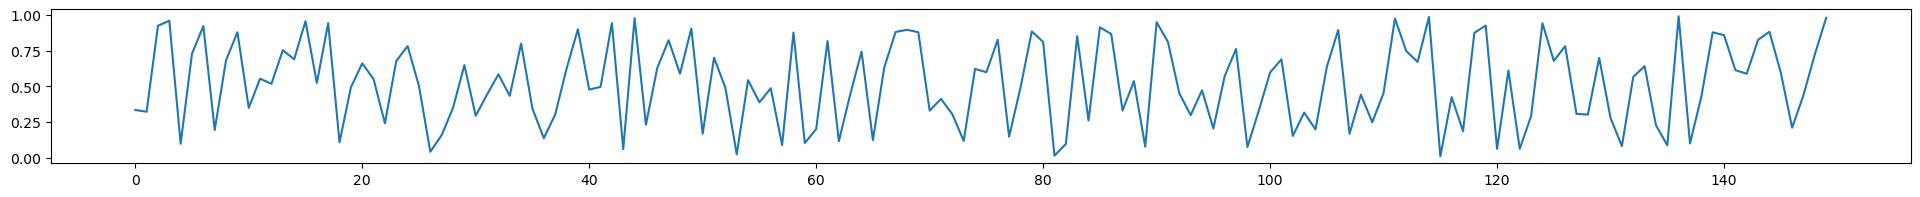

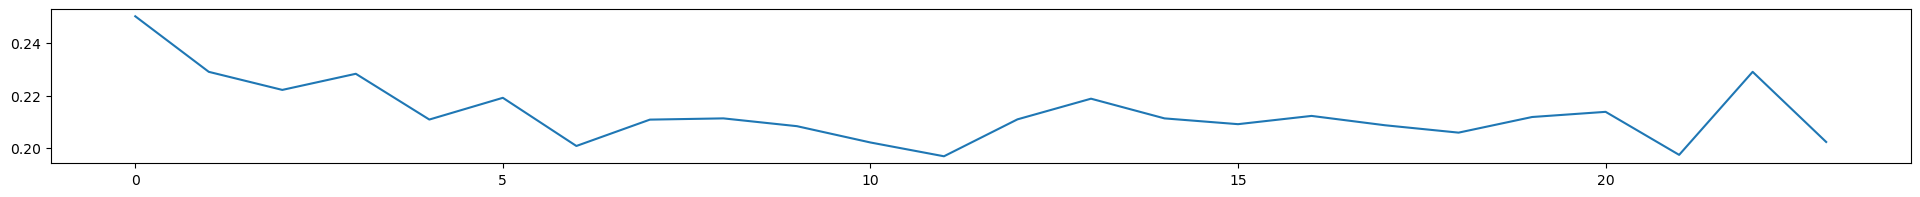

In [3]:
plt.figure(figsize = (24, 2))
plt.plot(sample_tensor[0, :, 0].cpu())
plt.show()

plt.figure(figsize = (24, 2))
plt.plot(prediction_np)
plt.show()